#### **To build an machine model using "ML algorithm" to predict heart disease of an person,so i chosen four models from supervised learning and they are Logistic Regression, Decision Tree, Random Forest, Support Vector Machine.**

### Step:1 **Goal setting for the project**

In [1]:
"""
Goal : To predict the heart disease of a person with the help of various features like age, sex, chest pain type, blood pressure, cholesterol level, blood sugar
ML algorithms used : Logistic Regression, Decision Tree, Random Forest, Support Vector Machine.
"""

'\nGoal : To predict the heart disease of a person with the help of various features like age, sex, chest pain type, blood pressure, cholesterol level, blood sugar\nML algorithms used : Logistic Regression, Decision Tree, Random Forest, Support Vector Machine.\n'

### Step:2 **Collect the dataset**

In [1]:
import pandas as pd
data = pd.read_csv("heart_disease_dataset.csv")
df = data.copy(deep=False)
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


### Step:3 **Prepare the dataset**

In [2]:
df.shape

(1000, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [4]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['age', 'gender', 'cholesterol', 'blood_pressure', 'heart_rate',
       'smoking', 'alcohol_intake', 'exercise_hours', 'family_history',
       'diabetes', 'obesity', 'stress_level', 'blood_sugar',
       'exercise_induced_angina', 'chest_pain_type', 'heart_disease'],
      dtype='object')

In [5]:
df = pd.get_dummies(df, drop_first=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   age                               1000 non-null   int64
 1   cholesterol                       1000 non-null   int64
 2   blood_pressure                    1000 non-null   int64
 3   heart_rate                        1000 non-null   int64
 4   exercise_hours                    1000 non-null   int64
 5   stress_level                      1000 non-null   int64
 6   blood_sugar                       1000 non-null   int64
 7   heart_disease                     1000 non-null   int64
 8   gender_Male                       1000 non-null   bool 
 9   smoking_Former                    1000 non-null   bool 
 10  smoking_Never                     1000 non-null   bool 
 11  alcohol_intake_Moderate           1000 non-null   bool 
 12  family_history_Yes                1

In [6]:
# Converting the data type of all the columns to int64
df = df.astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   age                               1000 non-null   int64
 1   cholesterol                       1000 non-null   int64
 2   blood_pressure                    1000 non-null   int64
 3   heart_rate                        1000 non-null   int64
 4   exercise_hours                    1000 non-null   int64
 5   stress_level                      1000 non-null   int64
 6   blood_sugar                       1000 non-null   int64
 7   heart_disease                     1000 non-null   int64
 8   gender_Male                       1000 non-null   int64
 9   smoking_Former                    1000 non-null   int64
 10  smoking_Never                     1000 non-null   int64
 11  alcohol_intake_Moderate           1000 non-null   int64
 12  family_history_Yes                1

In [56]:
df.rename(columns={
"chest_pain_type_Typical Angina":"chest_pain_type_Typical_Angina",
"chest_pain_type_Atypical Angina":"chest_pain_type_Atypical_Angina",
}, inplace=True)
df.columns = df.columns.str.replace("-", "_", regex=False)
df.columns

Index(['age', 'cholesterol', 'blood_pressure', 'heart_rate', 'exercise_hours',
       'stress_level', 'blood_sugar', 'heart_disease', 'gender_Male',
       'smoking_Former', 'smoking_Never', 'alcohol_intake_Moderate',
       'family_history_Yes', 'diabetes_Yes', 'obesity_Yes',
       'exercise_induced_angina_Yes', 'chest_pain_type_Atypical_Angina',
       'chest_pain_type_Non_anginal_Pain', 'chest_pain_type_Typical_Angina'],
      dtype='object')

In [57]:
df.head(3)

,age,cholesterol,blood_pressure,heart_rate,exercise_hours,stress_level,blood_sugar,heart_disease,gender_Male,smoking_Former,smoking_Never,alcohol_intake_Moderate,family_history_Yes,diabetes_Yes,obesity_Yes,exercise_induced_angina_Yes,chest_pain_type_Atypical_Angina,chest_pain_type_Non_anginal_Pain,chest_pain_type_Typical_Angina
0,75,228,119,66,1,8,119,1,0,0,0,0,0,0,1,1,1,0,0
1,48,204,165,62,5,9,70,0,1,0,0,0,0,0,0,1,0,0,1
2,53,234,91,67,3,5,196,1,1,0,1,0,1,0,1,1,1,0,0


### Step:4 **Feauture engineering**

<Axes: >

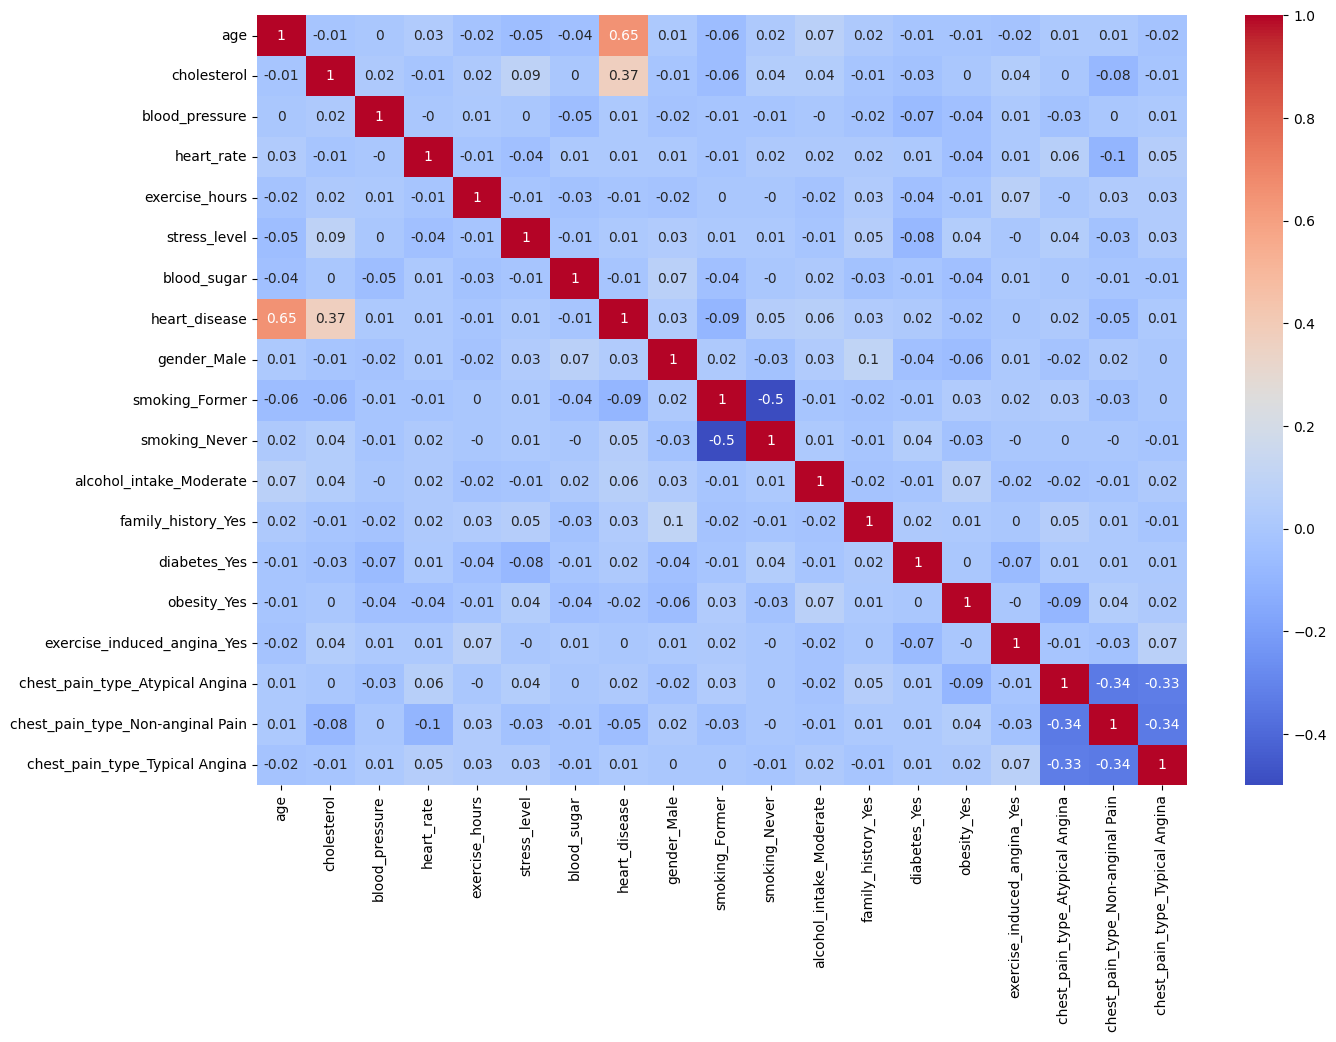

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation = df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(correlation.round(2), annot=True,cmap='coolwarm')

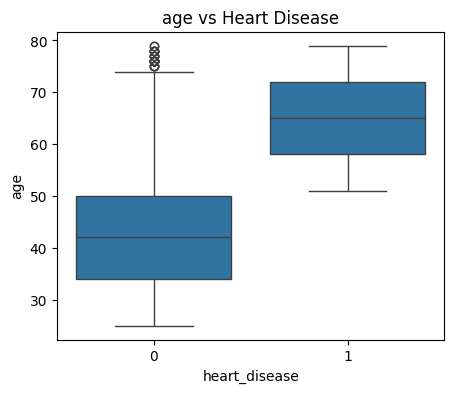

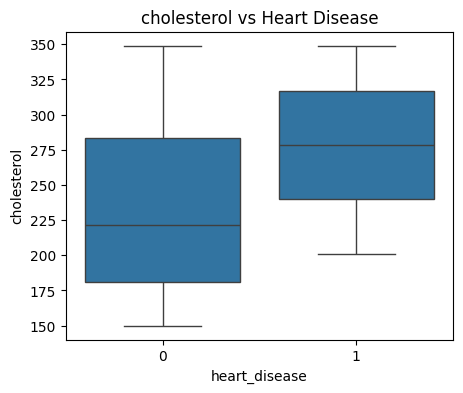

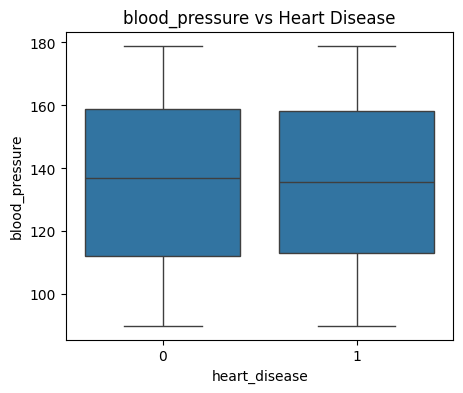

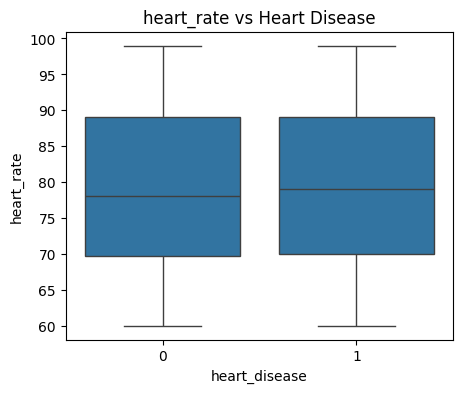

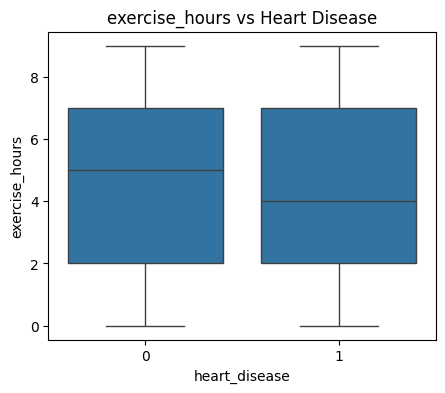

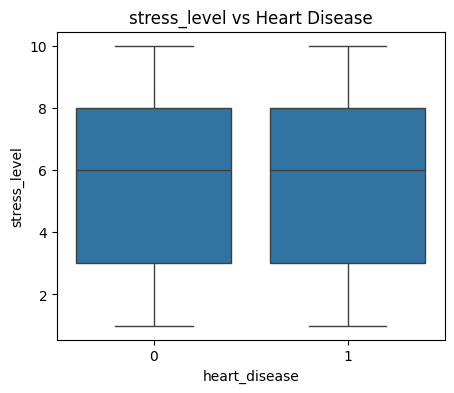

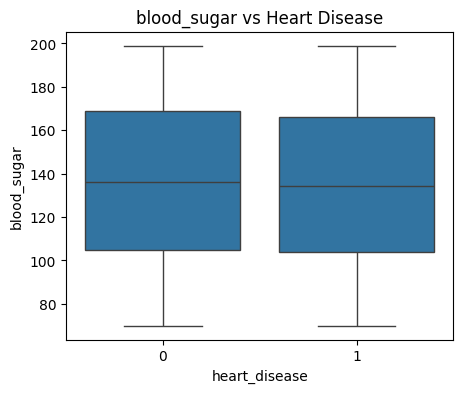

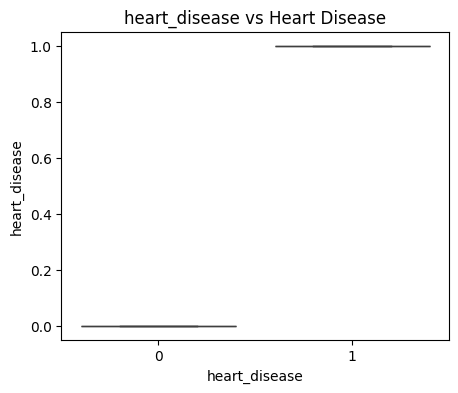

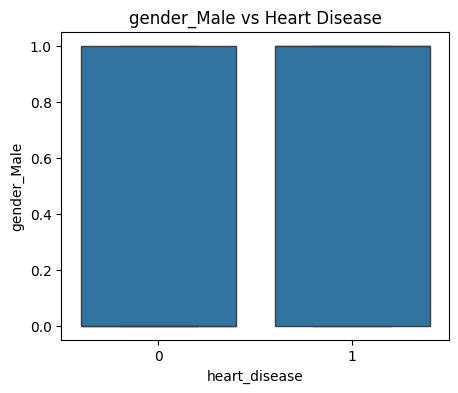

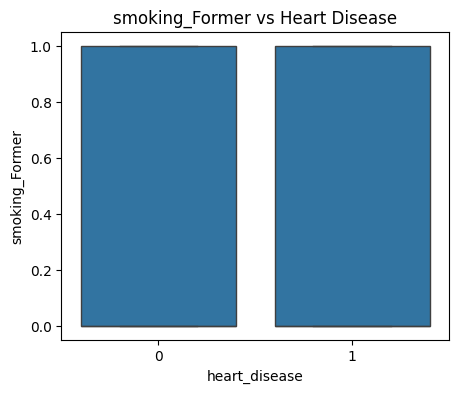

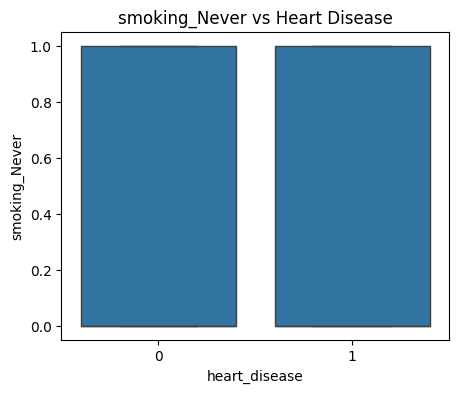

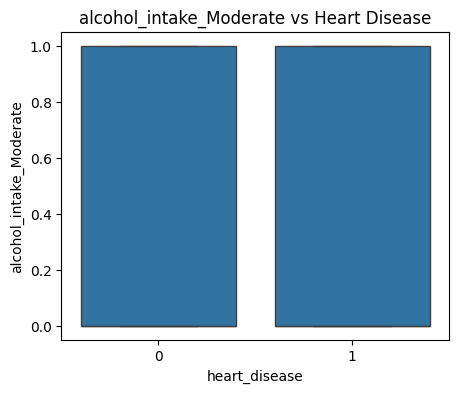

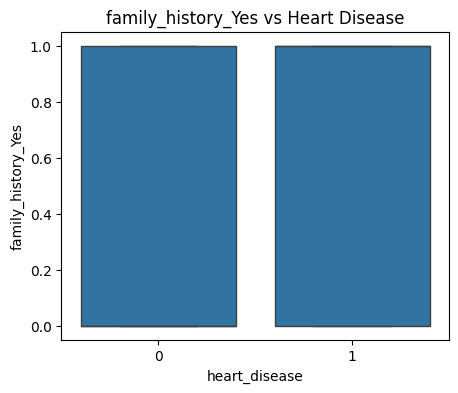

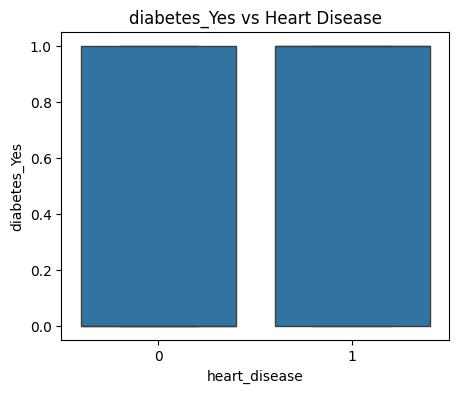

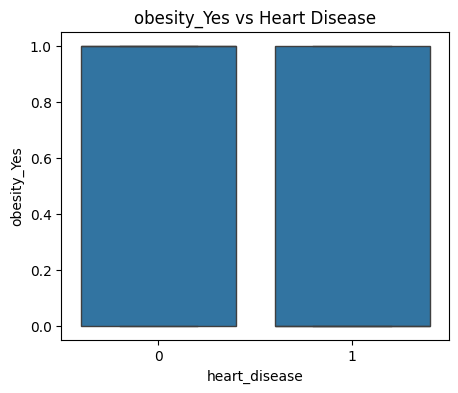

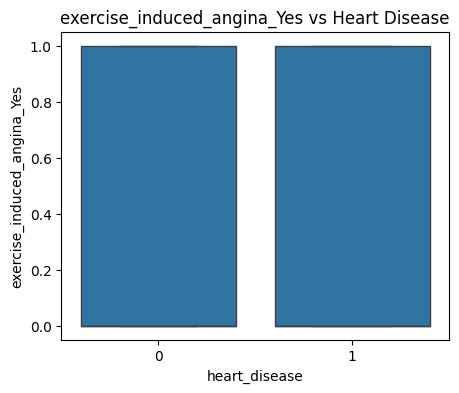

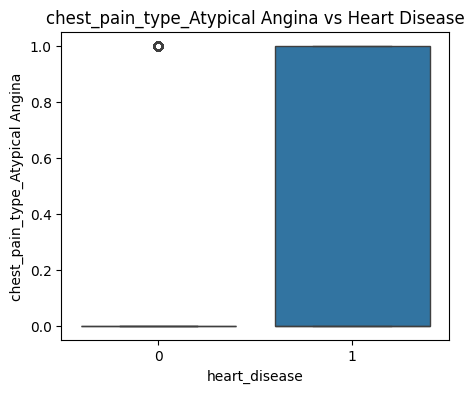

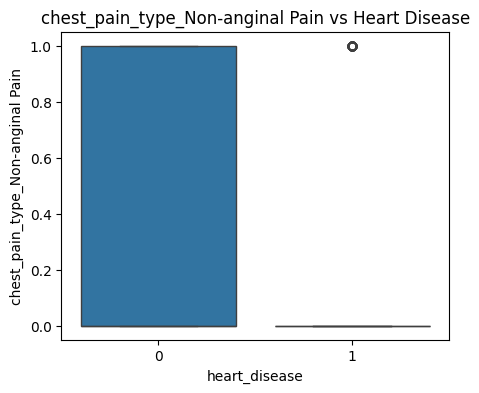

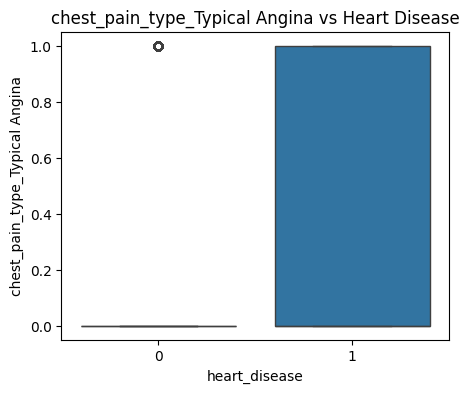

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
num_cols = df.select_dtypes(include=['int64']).columns
for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x="heart_disease", y=col, data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()

### Step:5 **Split the dataset for training and testing**

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
splitted_data = train_test_split(df,test_size=0.3)
train_data, test_data = splitted_data[0], splitted_data[1]
x_train = train_data.drop(columns=["heart_disease","exercise_induced_angina_Yes"])
y_train = train_data["heart_disease"]
x_test = test_data.drop(columns=["heart_disease","exercise_induced_angina_Yes"])
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Step:6 **Apply ml algorithm to training data to create a ml model**

In [59]:
# importing the ML algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [60]:
# Training the models on the training data
lg_model = LogisticRegression(random_state=123).fit(x_train_scaled, y_train)
dt_model = DecisionTreeClassifier(random_state=123).fit(x_train, y_train)
rf_model = RandomForestClassifier(random_state=123).fit(x_train, y_train)
svm_model = SVC(random_state=123).fit(x_train_scaled, y_train)

### Step:7 **Evaluating the model using test data**

In [61]:
lg_pred = lg_model.predict(x_test_scaled)
dt_pred = dt_model.predict(x_test)
rf_pred = rf_model.predict(x_test)
svm_pred = svm_model.predict(x_test_scaled)

In [62]:
true_labels = test_data["heart_disease"]
true_labels.value_counts()

heart_disease
0    169
1    131
Name: count, dtype: int64

In [63]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score,precision_score,recall_score
print("Logistic Regression:")
print(classification_report(true_labels, lg_pred))
print("---------------------------------")
print("Decision Tree:") 
print(classification_report(true_labels, dt_pred))
print("---------------------------------")
print("Random Forest:")
print(classification_report(true_labels, rf_pred))
print("---------------------------------")
print("Support Vector Machine:")
print(classification_report(true_labels, svm_pred))


Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       169
           1       0.85      0.79      0.82       131

    accuracy                           0.85       300
   macro avg       0.85      0.84      0.84       300
weighted avg       0.85      0.85      0.85       300

---------------------------------
Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       169
           1       1.00      1.00      1.00       131

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

---------------------------------
Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       169
           1       1.00      1.00      1.00       131

    accuracy                           1.00       300
   macro 

### Step:8 **Prediction summary**

In [64]:
print("Logistic Regression: Scores")
print("Accuracy:", accuracy_score(true_labels, lg_pred))
print("Precision:", precision_score(true_labels, lg_pred))
print("Recall:", recall_score(true_labels, lg_pred))
print("F1 Score:", f1_score(true_labels, lg_pred))

Logistic Regression: Scores
Accuracy: 0.8466666666666667
Precision: 0.8455284552845529
Recall: 0.7938931297709924
F1 Score: 0.8188976377952756


In [65]:
print("Decision Tree: Scores")
print("Accuracy:", accuracy_score(true_labels, dt_pred))
print("Precision:", precision_score(true_labels, dt_pred))
print("Recall:", recall_score(true_labels, dt_pred))
print("F1 Score:", f1_score(true_labels, dt_pred))

Decision Tree: Scores
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [66]:
print("Random Forest: Scores")
print("Accuracy", accuracy_score(true_labels, rf_pred))
print("Precision:", precision_score(true_labels, rf_pred))
print("Recall:", recall_score(true_labels, rf_pred))
print("F1 Score:", f1_score(true_labels, rf_pred))

Random Forest: Scores
Accuracy 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [67]:
print("SVC: Scores")
print("Accuracy:", accuracy_score(true_labels, svm_pred))
print("Precision:", precision_score(true_labels, svm_pred))
print("Recall:", recall_score(true_labels, svm_pred))
print("F1 Score:", f1_score(true_labels, svm_pred))

SVC: Scores
Accuracy: 0.89
Precision: 0.9083333333333333
Recall: 0.8320610687022901
F1 Score: 0.8685258964143426


In [68]:
import joblib
joblib.dump(lg_model, "logistic_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [69]:
x_test.columns

Index(['age', 'cholesterol', 'blood_pressure', 'heart_rate', 'exercise_hours',
       'stress_level', 'blood_sugar', 'gender_Male', 'smoking_Former',
       'smoking_Never', 'alcohol_intake_Moderate', 'family_history_Yes',
       'diabetes_Yes', 'obesity_Yes', 'chest_pain_type_Atypical_Angina',
       'chest_pain_type_Non_anginal_Pain', 'chest_pain_type_Typical_Angina'],
      dtype='object')